# A guide Portfolio Optimization Environment

This notebook aims to provide an example of using PortfolioOptimizationEnv (or POE) to train a reinforcement learning model that learns to solve the portfolio optimization problem.

In this document, we will reproduce a famous architecture called EIIE (ensemble of identical independent evaluators), introduced in the following paper:

- Zhengyao Jiang, Dixing Xu, & Jinjun Liang. (2017). A Deep Reinforcement Learning Framework for the Financial Portfolio Management Problem. https://doi.org/10.48550/arXiv.1706.10059.

It's advisable to read it to understand the algorithm implemented in this notebook.

### Note
If you're using this environment, consider citing the following paper (in adittion to FinRL references):

- Caio Costa, & Anna Costa (2023). POE: A General Portfolio Optimization Environment for FinRL. In *Anais do II Brazilian Workshop on Artificial Intelligence in Finance* (pp. 132–143). SBC. https://doi.org/10.5753/bwaif.2023.231144.

```
@inproceedings{bwaif,
 author = {Caio Costa and Anna Costa},
 title = {POE: A General Portfolio Optimization Environment for FinRL},
 booktitle = {Anais do II Brazilian Workshop on Artificial Intelligence in Finance},
 location = {João Pessoa/PB},
 year = {2023},
 keywords = {},
 issn = {0000-0000},
 pages = {132--143},
 publisher = {SBC},
 address = {Porto Alegre, RS, Brasil},
 doi = {10.5753/bwaif.2023.231144},
 url = {https://sol.sbc.org.br/index.php/bwaif/article/view/24959}
}

```

## Installation and imports

To run this notebook in google colab, uncomment the cells below.

In [232]:
# # install finrl library
# !sudo apt install swig
# !pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

In [233]:
## We also need to install quantstats, because the environment uses it to plot graphs
# !pip install quantstats

In [234]:
## Hide matplotlib warnings
# import warnings
# warnings.filterwarnings('ignore')

import logging
logging.getLogger('matplotlib.font_manager').disabled = True

#### Import the necessary code libraries

In [235]:
import torch

import numpy as np

from sklearn.preprocessing import MaxAbsScaler

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import GroupByScaler
from finrl.meta.env_portfolio_optimization.env_portfolio_optimization import PortfolioOptimizationEnv
from finrl.agents.portfolio_optimization.models import DRLAgent
from finrl.agents.portfolio_optimization.architectures import EIIE

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

## Fetch data

In his paper, *Jiang et al* creates a portfolio composed by the top-11 cryptocurrencies based on 30-days volume. Since it's not specified when this classification was done, it's difficult to reproduce, so we will use a similar approach in the Brazillian stock market:

- We select top-10 stocks from Brazillian stock market;
- For simplicity, we disconsider stocks that have missing data for the days in period 2011-01-01 to 2019-12-31 (9 years);

In [414]:
TOP_BRL =['000001.SS', '399001.SZ', '603000.SS','000035.SZ','002261.SZ','000938.SZ','600547.SS','600756.SS','601899.SS','601988.SS']


In [336]:
print(len(TOP_BRL))

portfolio_raw_df = YahooDownloader(start_date = '2018-01-01',
                                end_date = '2024-10-24',
                                ticker_list = TOP_BRL).fetch_data()
portfolio_raw_df

3


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (4941, 8)


,date,open,high,low,close,volume,tic,day
0,2018-01-02,3314.031006,3349.052979,3314.031006,3348.325928,202300,000001.SS,1
1,2018-01-02,11079.639648,11178.049805,11072.870117,11178.005859,97900,399001.SZ,1
2,2018-01-02,10.830000,10.940000,10.830000,10.328034,4156350,603000.SS,1
3,2018-01-03,3347.742920,3379.915039,3345.289062,3369.107910,213800,000001.SS,2
4,2018-01-03,11181.179688,11316.459961,11171.120117,11280.255859,115500,399001.SZ,2
...,...,...,...,...,...,...,...,...
4936,2024-10-21,10441.870117,10636.160156,10331.790039,10470.910156,3212800,399001.SZ,0
4937,2024-10-21,22.000000,22.750000,21.889999,22.309999,34505287,603000.SS,0
4938,2024-10-22,3263.822021,3294.960938,3255.137939,3285.866943,574900,000001.SS,1
4939,2024-10-22,10459.160156,10604.780273,10409.679688,10559.509766,2952400,399001.SZ,1


In [374]:
portfolio_raw_df.groupby("tic").count()

,date,open,high,low,close,volume,day,macd,boll_ub,boll_lb,...,net_lg_pct,net_elg_pct,spring_festival_pre_holiday,spring_festival_post_holiday,labor_day_pre_holiday,labor_day_post_holiday,national_day_pre_holiday,national_day_post_holiday,dayofmonth,dayofyear
tic,,,,,,,,,,,,,,,,,,,,,
000001.SS,1590,1590,1590,1590,1590,1590,1590,1590,1590,1590,...,1590,1590,1590,1590,1590,1590,1590,1590,1590,1590
399001.SZ,1590,1590,1590,1590,1590,1590,1590,1590,1590,1590,...,1590,1590,1590,1590,1590,1590,1590,1590,1590,1590
603000.SS,1590,1590,1590,1590,1590,1590,1590,1590,1590,1590,...,1590,1590,1590,1590,1590,1590,1590,1590,1590,1590


In [338]:
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.config import INDICATORS
fe = FeatureEngineer(use_technical_indicator=True,
                     tech_indicator_list = INDICATORS,
                     use_vix=True,
                     use_turbulence=True,
                     user_defined_feature = False)

processed = fe.preprocess_data(portfolio_raw_df)

Successfully added technical indicators


[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (1712, 8)
Successfully added vix
Successfully added turbulence index


In [339]:
import sys
# 添加环境路径
sys.path.append('/Users/pu17/Documents/stock/stock_price_prediction')
from feature.mysqlhandler import MySQLHandler
from config import OUTPUT_DIR
mysql_handler = MySQLHandler()
# 连接到数据库
mysql_handler.connect()
# 获取数据并重命名列
holiday_features = mysql_handler.fetch_table_as_dataframe('holiday_features_table').rename(columns={'trade_date': 'date'})
market_breadth = mysql_handler.fetch_table_as_dataframe('market_breadth_table').rename(columns={'trade_date': 'date'})
moneyflow_summary = mysql_handler.fetch_table_as_dataframe('moneyflow_summary_table').rename(columns={'trade_date': 'date'})

/Users/pu17/Documents/stock/stock_price_prediction/feature/mysqlhandler.py:268: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)


In [340]:
moneyflow_summary = moneyflow_summary.drop(columns=[
    'buy_sm_vol', 'buy_sm_amount', 'sell_sm_vol', 'sell_sm_amount',
    'buy_md_vol', 'buy_md_amount', 'sell_md_vol', 'sell_md_amount',
    'buy_lg_vol', 'buy_lg_amount', 'sell_lg_vol', 'sell_lg_amount',
    'buy_elg_vol', 'buy_elg_amount', 'sell_elg_vol', 'sell_elg_amount'
])
market_breadth['date'] = market_breadth['date'].astype(str)
moneyflow_summary['date'] = moneyflow_summary['date'].astype(str)
holiday_features['date'] = holiday_features['date'].astype(str)
# 检查转换是否成功
print(processed['date'].dtype)
print(market_breadth['date'].dtype)
print(moneyflow_summary['date'].dtype)
print(holiday_features['date'].dtype)

object
object
object
object


In [341]:
import pandas as pd
def select_exchange(row):
    if row['tic'] == '399001.SZ':
        return 'SZSE'
    elif row['tic'] in ['000001.SS', '603000.SS']:
        return 'SSE'
    return None

# 为 df1 添加一个新列 'exchange'，根据 'tic' 来选择合适的交易所
processed['exchange'] = processed.apply(select_exchange, axis=1)
holiday_features.drop(columns=['day'], inplace=True)

# 3. 左连接，基于 'date' 和 'exchange' 进行合并
processed = pd.merge(processed, market_breadth, how='left', on=['date', 'exchange'])

processed = pd.merge(processed, moneyflow_summary, how='left', on=['date', 'exchange'])
merged_df = pd.merge(processed, holiday_features, how='left', on='date')
portfolio_raw_df=merged_df.drop(columns=['exchange'])

portfolio_raw_df.head()

,date,open,high,low,close,volume,tic,day,macd,boll_ub,...,net_lg_pct,net_elg_pct,spring_festival_pre_holiday,spring_festival_post_holiday,labor_day_pre_holiday,labor_day_post_holiday,national_day_pre_holiday,national_day_post_holiday,dayofmonth,dayofyear
0,2018-01-02,3314.031006,3349.052979,3314.031006,3348.325928,202300,000001.SS,1,0.000000,3388.107080,...,0.000106,0.012361,0,0,0,0,0,0,2,2
1,2018-01-02,11079.639648,11178.049805,11072.870117,11178.005859,97900,399001.SZ,1,0.000000,3388.107080,...,-0.008774,0.009917,0,0,0,0,0,0,2,2
2,2018-01-02,10.830000,10.940000,10.830000,10.328034,4156350,603000.SS,1,0.000000,3388.107080,...,0.000106,0.012361,0,0,0,0,0,0,2,2
3,2018-01-03,3347.742920,3379.915039,3345.289062,3369.107910,213800,000001.SS,2,0.466262,3388.107080,...,-0.004923,0.000916,0,0,0,0,0,0,3,3
4,2018-01-03,11181.179688,11316.459961,11171.120117,11280.255859,115500,399001.SZ,2,2.294071,11373.734196,...,0.004139,0.013860,0,0,0,0,0,0,3,3


In [342]:
# print(portfolio_raw_df.isnull().sum())  # 打印每列中缺失值的数量
portfolio_raw_df = portfolio_raw_df.fillna(0)
print(portfolio_raw_df.isnull().sum()) 

date                            0
open                            0
high                            0
low                             0
close                           0
volume                          0
tic                             0
day                             0
macd                            0
boll_ub                         0
boll_lb                         0
rsi_30                          0
cci_30                          0
dx_30                           0
close_30_sma                    0
close_60_sma                    0
vix                             0
turbulence                      0
up_count                        0
down_count                      0
up_down_ratio                   0
market_breadth                  0
net_mf_vol                      0
net_mf_amount                   0
net_sm_vol                      0
net_sm_amount                   0
net_md_vol                      0
net_md_amount                   0
net_lg_vol                      0
net_lg_amount 

### Normalize Data

We normalize the data dividing the time series of each stock by its maximum value, so that the dataframe contains values between 0 and 1.

In [343]:
portfolio_norm_df = GroupByScaler(by="tic", scaler=MaxAbsScaler).fit_transform(portfolio_raw_df)
portfolio_norm_df

/Users/pu17/miniconda3/envs/finrobot/lib/python3.10/site-packages/finrl/meta/preprocessor/preprocessors.py:101: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.15401599 0.16277122 0.15759421 ... 0.40243624 0.52759802 0.50871717]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[select_mask, self.columns] = self.scalers[value].transform(
/Users/pu17/miniconda3/envs/finrobot/lib/python3.10/site-packages/finrl/meta/preprocessor/preprocessors.py:101: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.25 0.5  0.75 ... 0.75 1.   0.  ]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  X.loc[select_mask, self.columns] = self.scalers[value].transform(
/Users/pu17/miniconda3/envs/finrobot/lib/python3.10/site-packages/finrl/meta/preprocessor/preproce

,date,open,high,low,close,volume,tic,day,macd,boll_ub,...,net_lg_pct,net_elg_pct,spring_festival_pre_holiday,spring_festival_post_holiday,labor_day_pre_holiday,labor_day_post_holiday,national_day_pre_holiday,national_day_post_holiday,dayofmonth,dayofyear
0,2018-01-02,0.890608,0.897464,0.897426,0.901209,0.154016,000001.SS,0.25,0.000000,0.901426,...,0.001732,0.181446,0.0,0.0,0.0,0.0,0.0,0.000000,0.064516,0.005464
1,2018-01-02,0.680736,0.686061,0.705381,0.700278,0.017680,399001.SZ,0.25,0.000000,0.208048,...,-0.124275,0.131734,0.0,0.0,0.0,0.0,0.0,0.000000,0.064516,0.005464
2,2018-01-02,0.266486,0.255906,0.274177,0.247240,0.024267,603000.SS,0.25,0.000000,1.000000,...,0.001732,0.181446,0.0,0.0,0.0,0.0,0.0,0.000000,0.064516,0.005464
3,2018-01-03,0.899668,0.905734,0.905890,0.906803,0.162771,000001.SS,0.50,0.003381,0.901426,...,-0.080141,0.013447,0.0,0.0,0.0,0.0,0.0,0.000000,0.096774,0.008197
4,2018-01-03,0.686974,0.694556,0.711640,0.706683,0.020859,399001.SZ,0.50,0.003189,0.698408,...,0.058619,0.184105,0.0,0.0,0.0,0.0,0.0,0.000000,0.096774,0.008197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4765,2024-10-18,0.606344,0.651062,0.628491,0.648886,0.620151,399001.SZ,1.00,0.708765,0.714225,...,-0.073035,0.248309,0.0,0.0,0.0,0.0,0.0,0.300000,0.580645,0.797814
4766,2024-10-18,0.519439,0.524912,0.528608,0.522583,0.239651,603000.SS,1.00,0.188233,0.007437,...,-0.094532,0.252455,0.0,0.0,0.0,0.0,0.0,0.300000,0.580645,0.797814
4767,2024-10-21,0.880404,0.884496,0.877134,0.879619,0.508717,000001.SS,0.00,0.800454,0.950892,...,-0.060222,-0.200133,0.0,0.0,0.0,0.0,0.0,0.333333,0.677419,0.806011
4768,2024-10-21,0.641551,0.652802,0.658171,0.655980,0.580221,399001.SZ,0.00,0.717036,0.719304,...,-0.204084,-0.082012,0.0,0.0,0.0,0.0,0.0,0.333333,0.677419,0.806011


In [344]:
df_portfolio=portfolio_norm_df
df_portfolio_train = df_portfolio[(df_portfolio["date"] >= "2018-01-01") & (df_portfolio["date"] < "2024-02-31")]
df_portfolio_2023 = df_portfolio[(df_portfolio["date"] >= "2024-02-01") & (df_portfolio["date"] < "2024-06-31")]
df_portfolio_2024 = df_portfolio[(df_portfolio["date"] >= "2024-07-01") & (df_portfolio["date"] <= "2024-10-22")]

### Instantiate Environment

Using the `PortfolioOptimizationEnv`, it's easy to instantiate a portfolio optimization environment for reinforcement learning agents. In the example below, we use the dataframe created before to start an environment.

In [426]:
environment = PortfolioOptimizationEnv(
        df_portfolio_train,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=4,
        features=['open', 'high', 'low', 'close', 'volume', 'day', 'macd',
       'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma',
       'close_60_sma', 'vix', 'turbulence', 'up_count', 'down_count',
       'up_down_ratio', 'market_breadth', 'net_mf_vol', 'net_mf_amount',
       'net_sm_vol', 'net_sm_amount', 'net_md_vol', 'net_md_amount',
       'net_lg_vol', 'net_lg_amount', 'net_elg_vol', 'net_elg_amount',
       'net_sm_pct', 'net_md_pct', 'net_lg_pct', 'net_elg_pct',
       'spring_festival_pre_holiday', 'spring_festival_post_holiday',
       'labor_day_pre_holiday', 'labor_day_post_holiday',
       'national_day_pre_holiday', 'national_day_post_holiday', 'dayofmonth',
       'dayofyear'],
        normalize_df=None
    )

### Instantiate Model

Now, we can instantiate the model using FinRL API. In this example, we are going to use the EIIE architecture introduced by Jiang et. al.

:exclamation: **Note:** Remember to set the architecture's `time_window` parameter with the same value of the environment's `time_window`.

In [427]:
# set PolicyGradient parameters
model_kwargs = {
    "lr": 0.001,
    "policy": EIIE,
}

# here, we can set EIIE's parameters
policy_kwargs = {
    "k_size": 3,
    "time_window": 4,
    "initial_features":42,
}

model = DRLAgent(environment).get_model("pg", device, model_kwargs, policy_kwargs)

### Train Model

In [1]:
DRLAgent.train_model(model, episodes=260)

NameError: name 'DRLAgent' is not defined

### Save Model

In [419]:
torch.save(model.train_policy.state_dict(), "policy_EIIE2.pt")

## Test Model

### Instantiate different environments

Since we have three different periods of time, we need three different environments instantiated to simulate them.

In [429]:
environment_2023 = PortfolioOptimizationEnv(
    df_portfolio_2023,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=4,
    features=['open', 'high', 'low', 'close', 'volume', 'day', 'macd',
       'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma',
       'close_60_sma', 'vix', 'turbulence', 'up_count', 'down_count',
       'up_down_ratio', 'market_breadth', 'net_mf_vol', 'net_mf_amount',
       'net_sm_vol', 'net_sm_amount', 'net_md_vol', 'net_md_amount',
       'net_lg_vol', 'net_lg_amount', 'net_elg_vol', 'net_elg_amount',
       'net_sm_pct', 'net_md_pct', 'net_lg_pct', 'net_elg_pct',
       'spring_festival_pre_holiday', 'spring_festival_post_holiday',
       'labor_day_pre_holiday', 'labor_day_post_holiday',
       'national_day_pre_holiday', 'national_day_post_holiday', 'dayofmonth',
       'dayofyear'],
        #        "macd",
        #    "boll_ub", "boll_lb", "rsi_30", "cci_30", "dx_30", "close_30_sma",
        #    "close_60_sma", "vix", "turbulence", "up_count",
        #    "down_count", "up_down_ratio", "market_breadth", "net_mf_vol",
        #    "net_mf_amount", "net_sm_vol", "net_sm_amount", "net_md_vol",
        #    "net_md_amount", "net_lg_vol", "net_lg_amount", "net_elg_vol",
        #    "net_elg_amount", "net_sm_pct", "net_md_pct", "net_lg_pct",
        #    "net_elg_pct", "spring_festival_pre_holiday",
        #    "spring_festival_post_holiday", "labor_day_pre_holiday",
        #    "labor_day_post_holiday", "national_day_pre_holiday",
        #    "national_day_post_holiday", "dayofmonth", "dayofyear"],
    normalize_df=None
)

environment_2024 = PortfolioOptimizationEnv(
    df_portfolio_2024,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=4,
    features=['open', 'high', 'low', 'close', 'volume', 'day', 'macd',
       'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma',
       'close_60_sma', 'vix', 'turbulence', 'up_count', 'down_count',
       'up_down_ratio', 'market_breadth', 'net_mf_vol', 'net_mf_amount',
       'net_sm_vol', 'net_sm_amount', 'net_md_vol', 'net_md_amount',
       'net_lg_vol', 'net_lg_amount', 'net_elg_vol', 'net_elg_amount',
       'net_sm_pct', 'net_md_pct', 'net_lg_pct', 'net_elg_pct',
       'spring_festival_pre_holiday', 'spring_festival_post_holiday',
       'labor_day_pre_holiday', 'labor_day_post_holiday',
       'national_day_pre_holiday', 'national_day_post_holiday', 'dayofmonth',
       'dayofyear'],
            #   , "macd",
        #    "boll_ub", "boll_lb", "rsi_30", "cci_30", "dx_30", "close_30_sma",
        #    "close_60_sma", "vix", "turbulence", "up_count",
        #    "down_count", "up_down_ratio", "market_breadth", "net_mf_vol",
        #    "net_mf_amount", "net_sm_vol", "net_sm_amount", "net_md_vol",
        #    "net_md_amount", "net_lg_vol", "net_lg_amount", "net_elg_vol",
        #    "net_elg_amount", "net_sm_pct", "net_md_pct", "net_lg_pct",
        #    "net_elg_pct", "spring_festival_pre_holiday",
        #    "spring_festival_post_holiday", "labor_day_pre_holiday",
        #    "labor_day_post_holiday", "national_day_pre_holiday",
        #    "national_day_post_holiday", "dayofmonth", "dayofyear"],
    normalize_df=None
)

### Test EIIE architecture
Now, we can test the EIIE architecture in the three different test periods. It's important no note that, in this code, we load the saved policy even though it's not necessary just to show how to save and load your model.

In [430]:
EIIE_results = {
    "training": environment._asset_memory["final"],
    "2023": {},
    "2024": {}
}

# instantiate an architecture with the same arguments used in training
# and load with load_state_dict.
policy = EIIE(time_window=4, initial_features=42,device=device)
policy.load_state_dict(torch.load("policy_EIIE2.pt"))


# 2021
DRLAgent.DRL_validation(model, environment_2023, policy=policy)
EIIE_results["2023"]["value"] = environment_2023._asset_memory["final"]

# 2022
DRLAgent.DRL_validation(model, environment_2024, policy=policy)
EIIE_results["2024"]["value"] = environment_2024._asset_memory["final"]
# 打印环境中保存的动作
print("Actions memory:",pd.DataFrame(environment_2023._actions_memory))

Initial portfolio value:100000
Final portfolio value: 109962.2421875
Final accumulative portfolio value: 1.099622421875
Maximum DrawDown: -0.3028971041184545
Sharpe ratio: 0.7646624909118596
Initial portfolio value:100000
Final portfolio value: 116454.5
Final accumulative portfolio value: 1.164545
Maximum DrawDown: -0.133550018389042
Sharpe ratio: 1.589059344449887
Actions memory:                0             1             2             3
0   1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
1   2.412857e-04  2.025154e-30  5.867280e-26  9.997587e-01
2   2.287953e-08  4.173293e-26  4.257041e-22  1.000000e+00
3   3.129394e-07  7.310769e-16  3.373147e-12  9.999996e-01
4   7.567836e-07  9.362782e-24  6.250493e-14  9.999993e-01
..           ...           ...           ...           ...
83  9.999994e-01  4.747623e-36  9.928592e-27  6.223655e-07
84  9.999996e-01  1.222159e-36  1.057235e-28  4.169846e-07
85  1.211252e-03  1.378136e-32  1.653603e-24  9.987888e-01
86  3.600733e-07  4.360161

In [431]:
for i, action in enumerate(environment_2024._actions_memory):
    if not np.isnan(action).all():  # 如果 action 中不全是 NaN
        print(f"Action at step {i}: {action}")

Action at step 0: [1. 0. 0. 0.]
Action at step 1: [2.7219337e-05 9.3082154e-34 3.4800978e-26 9.9997282e-01]
Action at step 2: [1.0000000e+00 4.8710396e-40 1.1225657e-28 5.2276048e-12]
Action at step 3: [8.9731663e-03 8.0817664e-32 6.8220696e-22 9.9102682e-01]
Action at step 4: [9.9995375e-01 2.1101759e-32 4.8813385e-20 4.6227444e-05]
Action at step 5: [1.0208033e-02 1.1075544e-31 2.0566549e-17 9.8979199e-01]
Action at step 6: [9.9986207e-01 1.3458809e-32 9.8044717e-18 1.3796108e-04]
Action at step 7: [1.0000000e+00 1.3699076e-37 3.5562847e-27 7.7439983e-09]
Action at step 8: [3.5732737e-05 3.1029084e-34 3.7788052e-25 9.9996424e-01]
Action at step 9: [9.7503090e-01 2.8716378e-32 3.4714108e-24 2.4969162e-02]
Action at step 10: [3.6396709e-01 4.2534755e-31 9.1360506e-24 6.3603294e-01]
Action at step 11: [6.5722168e-07 9.7358938e-33 1.4915728e-26 9.9999928e-01]
Action at step 12: [9.5883095e-01 2.7025976e-32 7.3008372e-22 4.1169073e-02]
Action at step 13: [9.9996078e-01 2.2784298e-35 1.011

### Test Uniform Buy and Hold
For comparison, we will also test the performance of a uniform buy and hold strategy. In this strategy, the portfolio has no remaining cash and the same percentage of money is allocated in each asset.

In [435]:
UBAH_results = {
    "train": {},
    "2023": {},
    "2024": {}
}

PORTFOLIO_SIZE = len(TOP_BRL)

# train period
terminated = False
environment.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment.step(action)
UBAH_results["train"]["value"] = environment._asset_memory["final"]


# 2021
terminated = False
environment_2023.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2023.step(action)
UBAH_results["2023"]["value"] = environment_2023._asset_memory["final"]

# 2022
terminated = False
environment_2024.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2024.step(action)
UBAH_results["2024"]["value"] = environment_2024._asset_memory["final"]

Initial portfolio value:100000
Final portfolio value: 140705.09375
Final accumulative portfolio value: 1.4070509375
Maximum DrawDown: -0.38288282178864463
Sharpe ratio: 0.35348035942125505
Initial portfolio value:100000
Final portfolio value: 104296.671875
Final accumulative portfolio value: 1.04296671875
Maximum DrawDown: -0.17639807813336705
Sharpe ratio: 0.5729623120241365
Initial portfolio value:100000
Final portfolio value: 115151.0625
Final accumulative portfolio value: 1.151510625
Maximum DrawDown: -0.12962929136233414
Sharpe ratio: 1.5542830895323938


### Plot graphics

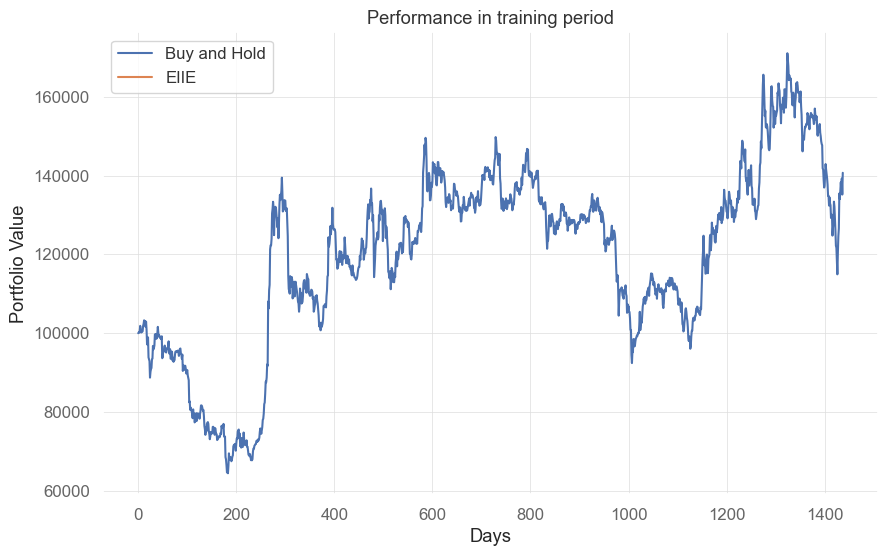

In [436]:
import matplotlib.pyplot as plt
%matplotlib inline 

plt.plot(UBAH_results["train"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["training"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in training period")
plt.legend()

plt.show()

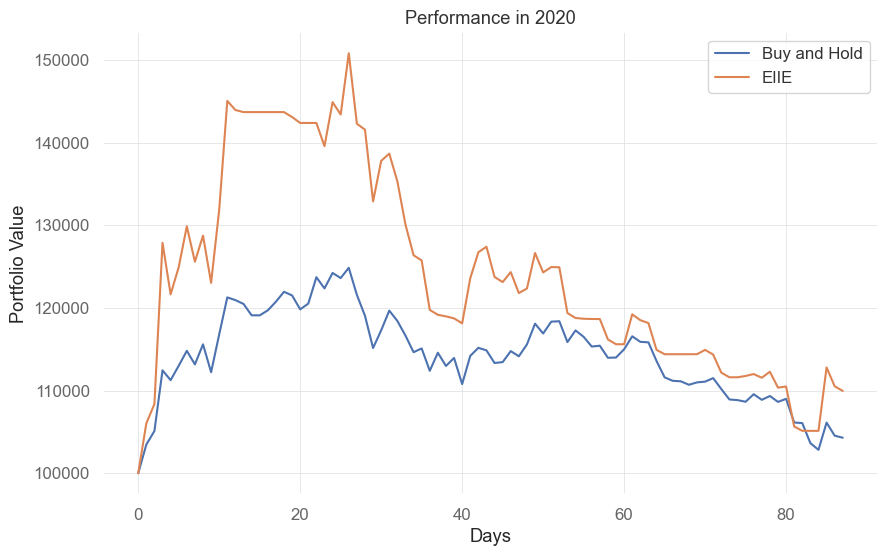

In [437]:
plt.plot(UBAH_results["2023"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2023"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2020")
plt.legend()

plt.show()

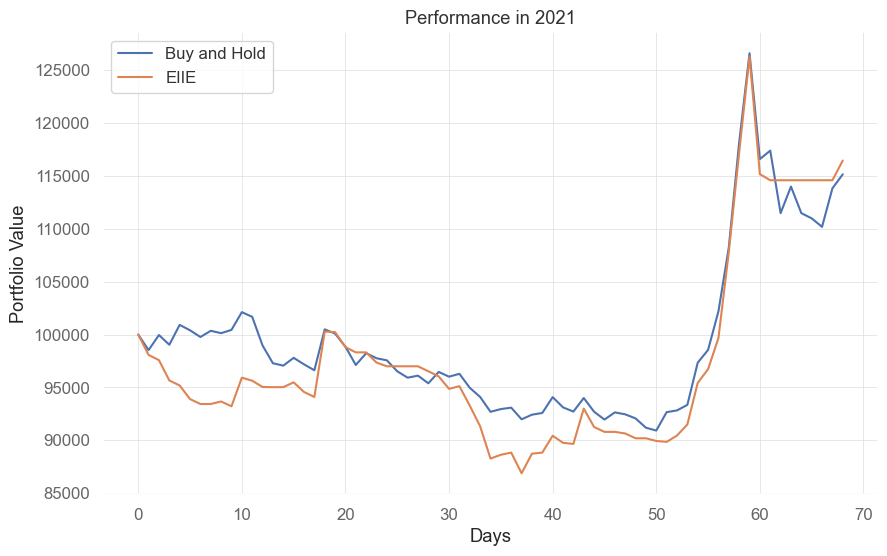

In [438]:
plt.plot(UBAH_results["2024"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2024"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2021")
plt.legend()

plt.show()

In [257]:
plt.plot(UBAH_results["2022"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2022"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2022")
plt.legend()

plt.show()

KeyError: '2022'

We can see that the agent is able to learn a good policy but its performance is worse the more the test period advances into the future. To get a better performance in 2022, for example, the agent should probably be trained again using more recent data.